In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = "/content/drive/MyDrive/PD_Project"
os.makedirs(project_path, exist_ok=True)
print("Project folder ready")

Project folder ready


In [3]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score


In [4]:
!ls

drive  handwriting_dataset  sample_data


In [5]:
from google.colab import files
files.upload()

Saving augmented_hw_dataset.zip to augmented_hw_dataset.zip


In [6]:
!unzip augmented*.zip -d handwriting_dataset

Archive:  augmented_hw_dataset.zip
   creating: handwriting_dataset/augmented_hw_dataset/
  inflating: handwriting_dataset/augmented_hw_dataset/dtw_distances.csv  
   creating: handwriting_dataset/augmented_hw_dataset/spiral/
   creating: handwriting_dataset/augmented_hw_dataset/spiral/testing/
   creating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V01HE01.png  
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V02HE01.png  
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V03HE1.png  
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V04HE01.png  
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V05HE01.png  
  inflating: handwriting_dataset/augmented_hw_dataset/spiral/testing/healthy/aug_0_V06HE01.png  
  inflating: handwriting_dataset/augmented_hw

In [7]:
BASE_PATH = "/content/handwriting_dataset/augmented_hw_dataset"


In [8]:
spiral_train_dir = BASE_PATH + "/spiral/training"
spiral_val_dir   = BASE_PATH + "/spiral/validation"
spiral_test_dir  = BASE_PATH + "/spiral/testing"

In [9]:
wave_train_dir = BASE_PATH + "/wave/training"
wave_val_dir   = BASE_PATH + "/wave/validation"
wave_test_dir  = BASE_PATH + "/wave/testing"

In [10]:
import os

print("Spiral train classes:", os.listdir(spiral_train_dir))
print("Wave train classes:", os.listdir(wave_train_dir))


Spiral train classes: ['parkinson', 'healthy']
Wave train classes: ['parkinson', 'healthy']


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 256
BATCH_SIZE = 32



In [12]:
spiral_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15
)


In [13]:
wave_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05
)

In [14]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [15]:
spiral_train_gen = spiral_train_datagen.flow_from_directory(
    spiral_train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

spiral_val_gen = val_datagen.flow_from_directory(
    spiral_val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

spiral_test_gen = test_datagen.flow_from_directory(
    spiral_test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [16]:
wave_train_gen = wave_train_datagen.flow_from_directory(
    wave_train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

wave_val_gen = val_datagen.flow_from_directory(
    wave_val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

wave_test_gen = test_datagen.flow_from_directory(
    wave_test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 288 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [17]:
spiral_labels = spiral_train_gen.classes
spiral_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(spiral_labels),
    y=spiral_labels
)
spiral_class_weights = dict(enumerate(spiral_class_weights))

wave_labels = wave_train_gen.classes
wave_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(wave_labels),
    y=wave_labels
)
wave_class_weights = dict(enumerate(wave_class_weights))

In [18]:
def build_resnet():
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [19]:
resnet_spiral = build_resnet()
resnet_wave   = build_resnet()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [20]:
spiral_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("resnet_spiral_best.keras", save_best_only=True)
]

resnet_spiral.fit(
    spiral_train_gen,
    validation_data=spiral_val_gen,
    epochs=20,
    class_weight=spiral_class_weights,
    callbacks=spiral_callbacks
)



Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5451 - loss: 0.8083 - val_accuracy: 0.5694 - val_loss: 0.6847
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4896 - loss: 0.8134 - val_accuracy: 0.5833 - val_loss: 0.6917
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 757ms/step - accuracy: 0.5174 - loss: 0.7951 - val_accuracy: 0.5556 - val_loss: 0.6746
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 936ms/step - accuracy: 0.5174 - loss: 0.7600 - val_accuracy: 0.6806 - val_loss: 0.6713
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 571ms/step - accuracy: 0.4965 - loss: 0.7827 - val_accuracy: 0.5417 - val_loss: 0.6774
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 882ms/step - accuracy: 0.4583 - loss: 0.8111 - val_accuracy: 0.6806 - val_loss: 0.6654
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 703ms/step - accuracy: 0.5035 - loss: 0.7917 - val_accuracy: 0.7083 - val_loss: 0.6640
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 848ms/step - accuracy: 0.5069 - loss: 0.7659 - val_accuracy: 0.7083 - val_loss: 0.6

In [21]:
for layer in resnet_spiral.layers[-20:]:
    layer.trainable = True

resnet_spiral.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_spiral.fit(
    spiral_train_gen,
    validation_data=spiral_val_gen,
    epochs=10
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5729 - loss: 0.6877 - val_accuracy: 0.6250 - val_loss: 0.6406
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 580ms/step - accuracy: 0.6285 - loss: 0.6463 - val_accuracy: 0.6667 - val_loss: 0.6381
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 815ms/step - accuracy: 0.6319 - loss: 0.6420 - val_accuracy: 0.6250 - val_loss: 0.6354
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - accuracy: 0.6806 - loss: 0.6112 - val_accuracy: 0.6111 - val_loss: 0.6342
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 662ms/step - accuracy: 0.6354 - loss: 0.6210 - val_accuracy: 0.6389 - val_loss: 0.6317
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 629ms/step - accuracy: 0.6875 - loss: 0.5918 - val_accuracy: 0.7083 - val_loss: 0.6343
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 578ms/step - accuracy: 0.6771 - loss: 0.5941 - val_accuracy: 0.7083 - val_loss: 0.6434
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 819ms/step - accuracy: 0.7083 - loss: 0.5837 - val_accuracy: 0.6528 - val_loss: 0

In [22]:
wave_callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("resnet_wave_best.keras", save_best_only=True)
]

resnet_wave.fit(
    wave_train_gen,
    validation_data=wave_val_gen,
    epochs=20,
    class_weight=wave_class_weights,
    callbacks=wave_callbacks
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5035 - loss: 0.8062 - val_accuracy: 0.5000 - val_loss: 0.7096
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 756ms/step - accuracy: 0.5521 - loss: 0.7359 - val_accuracy: 0.4722 - val_loss: 0.6990
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 892ms/step - accuracy: 0.5174 - loss: 0.8067 - val_accuracy: 0.5000 - val_loss: 0.7095
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 621ms/step - accuracy: 0.5035 - loss: 0.7847 - val_accuracy: 0.4861 - val_loss: 0.7004
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 994ms/step - accuracy: 0.4583 - loss: 0.8080 - val_accuracy: 0.5833 - val_loss: 0.6978
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 789ms/step - accuracy: 0.5035 - loss: 0.7546 - val_accuracy: 0.5833 - val_loss: 0.6967
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 979ms/step - accuracy: 0.5312 - loss: 0.7500 - val_accuracy: 0.4722 - val_loss: 0.6961
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 620ms/step - accuracy: 0.5312 - loss: 0.7028 - val_accuracy: 0.4861 - val_loss: 0

In [23]:
print("Spiral test accuracy")
resnet_spiral.evaluate(spiral_test_gen)

print("Wave test accuracy")
resnet_wave.evaluate(wave_test_gen)


Spiral test accuracy
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6133 - loss: 0.5955
Wave test accuracy
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 651ms/step - accuracy: 0.5733 - loss: 0.6831


[0.6830989718437195, 0.5733333230018616]

In [24]:
spiral_probs = resnet_spiral.predict(spiral_test_gen)
wave_probs   = resnet_wave.predict(wave_test_gen)

final_probs = (0.7 * spiral_probs) + (0.3 * wave_probs)
final_preds = (final_probs > 0.5).astype(int)

true_labels = spiral_test_gen.classes

fusion_accuracy = accuracy_score(true_labels, final_preds)
print("Final fused accuracy:", fusion_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Final fused accuracy: 0.6133333333333333


In [25]:
resnet_spiral.save("/content/drive/MyDrive/PD_Project/handwriting_resnet_spiral_final.keras")
resnet_wave.save("/content/drive/MyDrive/PD_Project/handwriting_resnet_wave_final.keras")

MobileNetV2

In [27]:
from tensorflow.keras.applications import MobileNetV2


In [26]:
def build_mobilenet():
    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model



In [28]:
mobilenet_spiral = build_mobilenet()
mobilenet_wave   = build_mobilenet()



/tmp/ipykernel_28814/322286107.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [29]:
spiral_m_callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True),
    ModelCheckpoint("mobilenet_spiral_best.keras", save_best_only=True)
]

mobilenet_spiral.fit(
    spiral_train_gen,
    validation_data=spiral_val_gen,
    epochs=25,
    class_weight=spiral_class_weights,
    callbacks=spiral_m_callbacks
)


Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.5521 - loss: 0.7313 - val_accuracy: 0.7500 - val_loss: 0.6071
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 837ms/step - accuracy: 0.6007 - loss: 0.6752 - val_accuracy: 0.7083 - val_loss: 0.5816
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - accuracy: 0.6840 - loss: 0.6023 - val_accuracy: 0.7361 - val_loss: 0.5530
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 848ms/step - accuracy: 0.6736 - loss: 0.5796 - val_accuracy: 0.7917 - val_loss: 0.5276
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 611ms/step - accuracy: 0.6944 - loss: 0.5679 - val_accuracy: 0.7917 - val_loss: 0.5115
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 717ms/step - accuracy: 0.7535 - loss: 0.5106 - val_accuracy: 0.7917 - val_loss: 0.4997
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 642ms/step - accuracy: 0.7188 - loss: 0.5319 - val_accuracy: 0.8056 - val_loss: 0.4866
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - accuracy: 0.7674 - loss: 0.5080 - val_accuracy: 0.7917 - val_loss: 0

In [30]:
wave_m_callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("mobilenet_wave_best.keras", save_best_only=True)
]

mobilenet_wave.fit(
    wave_train_gen,
    validation_data=wave_val_gen,
    epochs=20,
    class_weight=wave_class_weights,
    callbacks=wave_m_callbacks
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5139 - loss: 0.8198 - val_accuracy: 0.3611 - val_loss: 0.7627
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 661ms/step - accuracy: 0.5243 - loss: 0.7303 - val_accuracy: 0.4444 - val_loss: 0.7170
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5903 - loss: 0.7032 - val_accuracy: 0.5417 - val_loss: 0.6715
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 667ms/step - accuracy: 0.6007 - loss: 0.6646 - val_accuracy: 0.6528 - val_loss: 0.6397
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 921ms/step - accuracy: 0.6806 - loss: 0.6025 - val_accuracy: 0.6806 - val_loss: 0.6152
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 668ms/step - accuracy: 0.7188 - loss: 0.5659 - val_accuracy: 0.7083 - val_loss: 0.5921
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 881ms/step - accuracy: 0.6944 - loss: 0.5790 - val_accuracy: 0.7083 - val_loss: 0.5742
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 698ms/step - accuracy: 0.7153 - loss: 0.5624 - val_accuracy: 0.7361 - val_loss: 0.55

In [31]:
print("MobileNetV2 Spiral Test Result")
mobilenet_spiral.evaluate(spiral_test_gen)

print("MobileNetV2 Wave Test Result")
mobilenet_wave.evaluate(wave_test_gen)


MobileNetV2 Spiral Test Result
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8000 - loss: 0.4615
MobileNetV2 Wave Test Result
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9067 - loss: 0.3289


[0.32891324162483215, 0.9066666960716248]

In [32]:
spiral_probs_m = mobilenet_spiral.predict(spiral_test_gen)
wave_probs_m   = mobilenet_wave.predict(wave_test_gen)

final_probs = (0.85 * spiral_probs_m) + (0.15 * wave_probs_m)
final_preds = (final_probs > 0.5).astype(int)

fusion_acc_mobilenet = accuracy_score(
    spiral_test_gen.classes,
    final_preds
)

print("Fusion Accuracy using MobileNetV2:", fusion_acc_mobilenet)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Fusion Accuracy using MobileNetV2: 0.8133333333333334


In [33]:
mobilenet_spiral.save("/content/drive/MyDrive/PD_Project/mobilenet_spiral_final.keras")
mobilenet_wave.save("/content/drive/MyDrive/PD_Project/mobilenet_wave_final.keras")


EfficientNetB0

In [34]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import DenseNet121


In [35]:
def build_efficientnet():
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [36]:
effnet_spiral = build_efficientnet()
effnet_wave   = build_efficientnet()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
eff_spiral_cb = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("effnet_spiral_best.keras", save_best_only=True)
]

effnet_spiral.fit(
    spiral_train_gen,
    validation_data=spiral_val_gen,
    epochs=20,
    class_weight=spiral_class_weights,
    callbacks=eff_spiral_cb
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.5000 - loss: 0.7024 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 552ms/step - accuracy: 0.4861 - loss: 0.7003 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 930ms/step - accuracy: 0.5174 - loss: 0.6944 - val_accuracy: 0.5417 - val_loss: 0.6932
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 550ms/step - accuracy: 0.4861 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 659ms/step - accuracy: 0.4792 - loss: 0.7027 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 624ms/step - accuracy: 0.5312 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 565ms/step - accuracy: 0.4479 - loss: 0.7062 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 786ms/step - accuracy: 0.5000 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0

In [38]:
eff_wave_cb = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("effnet_wave_best.keras", save_best_only=True)
]

effnet_wave.fit(
    wave_train_gen,
    validation_data=wave_val_gen,
    epochs=10,
    class_weight=wave_class_weights,
    callbacks=eff_wave_cb
)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4792 - loss: 0.7017 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 644ms/step - accuracy: 0.4861 - loss: 0.7010 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 799ms/step - accuracy: 0.4792 - loss: 0.7028 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 600ms/step - accuracy: 0.4688 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 839ms/step - accuracy: 0.4965 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 805ms/step - accuracy: 0.4618 - loss: 0.7025 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 961ms/step - accuracy: 0.5035 - loss: 0.6981 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 692ms/step - accuracy: 0.5069 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0

In [39]:
print("EfficientNet Spiral")
effnet_spiral.evaluate(spiral_test_gen)

print("EfficientNet Wave")
effnet_wave.evaluate(wave_test_gen)

EfficientNet Spiral
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4867 - loss: 0.6932
EfficientNet Wave
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5267 - loss: 0.6930


[0.6929870843887329, 0.5266666412353516]

In [40]:
effnet_spiral.save("effnet_spiral_final.keras")
effnet_wave.save("effnet_wave_final.keras")

DenseNet121

In [41]:
def build_densenet():
    base = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [42]:

dense_spiral = build_densenet()
dense_wave   = build_densenet()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [43]:
dense_spiral_cb = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("densenet_spiral_best.keras", save_best_only=True)
]

dense_spiral.fit(
    spiral_train_gen,
    validation_data=spiral_val_gen,
    epochs=20,
    class_weight=spiral_class_weights,
    callbacks=dense_spiral_cb
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.4826 - loss: 0.8822 - val_accuracy: 0.6944 - val_loss: 0.6355
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 919ms/step - accuracy: 0.5938 - loss: 0.6937 - val_accuracy: 0.6667 - val_loss: 0.5984
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 740ms/step - accuracy: 0.6007 - loss: 0.7112 - val_accuracy: 0.7361 - val_loss: 0.5676
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 929ms/step - accuracy: 0.6528 - loss: 0.6537 - val_accuracy: 0.7361 - val_loss: 0.5453
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 751ms/step - accuracy: 0.6285 - loss: 0.6188 - val_accuracy: 0.7500 - val_loss: 0.5253
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 960ms/step - accuracy: 0.6181 - loss: 0.6389 - val_accuracy: 0.7500 - val_loss: 0.5065
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 757ms/step - accuracy: 0.6806 - loss: 0.5826 - val_accuracy: 0.7361 - val_loss: 0.5003
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7326 - loss: 0.5643 - val_accuracy: 0.7361 - val_loss: 0.48

In [44]:
dense_wave_cb = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("densenet_wave_best.keras", save_best_only=True)
]

dense_wave.fit(
    wave_train_gen,
    validation_data=wave_val_gen,
    epochs=20,
    class_weight=wave_class_weights,
    callbacks=dense_wave_cb
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.4792 - loss: 0.7885 - val_accuracy: 0.5694 - val_loss: 0.6862
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 984ms/step - accuracy: 0.5764 - loss: 0.7073 - val_accuracy: 0.6667 - val_loss: 0.6146
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 875ms/step - accuracy: 0.6111 - loss: 0.6447 - val_accuracy: 0.7778 - val_loss: 0.5715
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 835ms/step - accuracy: 0.6910 - loss: 0.5876 - val_accuracy: 0.7500 - val_loss: 0.5692
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 959ms/step - accuracy: 0.7118 - loss: 0.5782 - val_accuracy: 0.7778 - val_loss: 0.5270
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 795ms/step - accuracy: 0.7431 - loss: 0.5517 - val_accuracy: 0.7917 - val_loss: 0.5070
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7153 - loss: 0.5458 - val_accuracy: 0.7917 - val_loss: 0.4944
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 782ms/step - accuracy: 0.7917 - loss: 0.5019 - val_accuracy: 0.8056 - val_loss: 0.47

In [45]:
print("EfficientNet Spiral")
effnet_spiral.evaluate(spiral_test_gen)

print("EfficientNet Wave")
effnet_wave.evaluate(wave_test_gen)

print("DenseNet Spiral")
dense_spiral.evaluate(spiral_test_gen)

print("DenseNet Wave")
dense_wave.evaluate(wave_test_gen)


EfficientNet Spiral
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4867 - loss: 0.6932
EfficientNet Wave
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5267 - loss: 0.6930
DenseNet Spiral
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.7933 - loss: 0.4637
DenseNet Wave
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8933 - loss: 0.3335


[0.3334885239601135, 0.8933333158493042]

In [47]:
effnet_spiral.save("/content/drive/MyDrive/PD_Project_handwriting_models/effnet_spiral_final.keras")
effnet_wave.save("/content/drive/MyDrive/PD_Project_handwriting_models/effnet_wave_final.keras")

dense_spiral.save("/content/drive/MyDrive/PD_Project_handwriting_models/densenet_spiral_final.keras")
dense_wave.save("/content/drive/MyDrive/PD_Project_handwriting_models/densenet_wave_final.keras")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PD_Project_handwriting_models/effnet_spiral_final.keras'

In [48]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [49]:
def evaluate_model(model, test_generator, threshold=0.5, title="Model"):

    probs = model.predict(test_generator)
    preds = (probs > threshold).astype(int)
    true_labels = test_generator.classes

    acc = accuracy_score(true_labels, preds)
    prec = precision_score(true_labels, preds)
    rec = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)

    print(title)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print()
    print("Classification Report")
    print(classification_report(true_labels, preds))

    return true_labels, preds


In [50]:
def plot_confusion_matrix(y_true, y_pred, classes=["Healthy", "Parkinson"]):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()


    plt.xticks([0,1], classes)
    plt.yticks([0,1], classes)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     ha="center",
                     va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step
ResNet50 Spiral
Accuracy: 0.6133333333333333
Precision: 0.7428571428571429
Recall: 0.3466666666666667
F1 Score: 0.4727272727272727

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.88      0.69        75
           1       0.74      0.35      0.47        75

    accuracy                           0.61       150
   macro avg       0.66      0.61      0.58       150
weighted avg       0.66      0.61      0.58       150



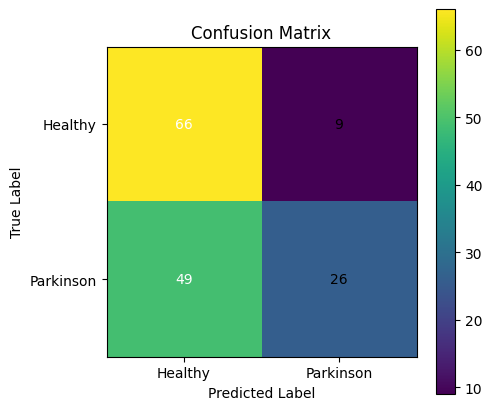

In [51]:
y_true, y_pred = evaluate_model(
    resnet_spiral,
    spiral_test_gen,
    threshold=0.5,
    title="ResNet50 Spiral"
)

plot_confusion_matrix(y_true, y_pred)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
MobileNetV2 Spiral
Accuracy: 0.8
Precision: 0.8461538461538461
Recall: 0.7333333333333333
F1 Score: 0.7857142857142857

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        75
           1       0.85      0.73      0.79        75

    accuracy                           0.80       150
   macro avg       0.81      0.80      0.80       150
weighted avg       0.81      0.80      0.80       150



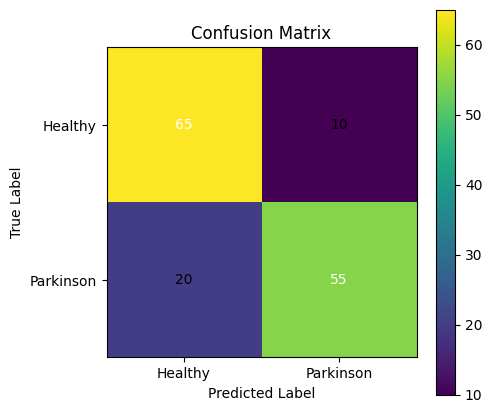

In [52]:
y_true, y_pred = evaluate_model(
    mobilenet_spiral,
    spiral_test_gen,
    threshold=0.5,
    title="MobileNetV2 Spiral"
)

plot_confusion_matrix(y_true, y_pred)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
ResNet50 Wave
Accuracy: 0.5
Precision: 0.5
Recall: 1.0
F1 Score: 0.6666666666666666

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        75
           1       0.50      1.00      0.67        75

    accuracy                           0.50       150
   macro avg       0.25      0.50      0.33       150
weighted avg       0.25      0.50      0.33       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


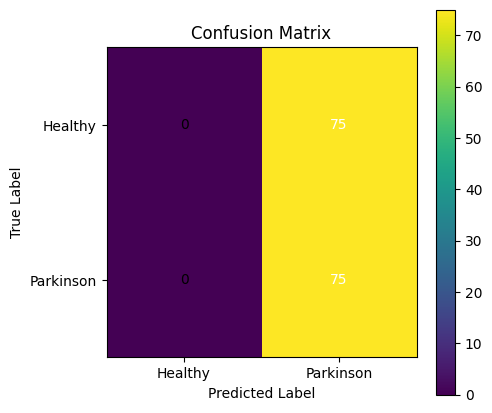

In [53]:
y_true, y_pred = evaluate_model(
    resnet_wave,
    wave_test_gen,
    threshold=0.4,
    title="ResNet50 Wave"
)

plot_confusion_matrix(y_true, y_pred)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
MobileNetV2 Wave
Accuracy: 0.86
Precision: 0.8068181818181818
Recall: 0.9466666666666667
F1 Score: 0.8711656441717791

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.77      0.85        75
           1       0.81      0.95      0.87        75

    accuracy                           0.86       150
   macro avg       0.87      0.86      0.86       150
weighted avg       0.87      0.86      0.86       150



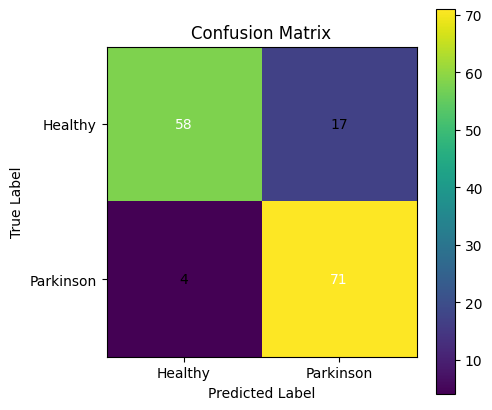

In [54]:
y_true, y_pred = evaluate_model(
    mobilenet_wave,
    wave_test_gen,
    threshold=0.4,
    title="MobileNetV2 Wave"
)

plot_confusion_matrix(y_true, y_pred)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 365ms/step
Fused Handwriting Model
Accuracy: 0.8133333333333334
Precision: 0.8615384615384616
Recall: 0.7466666666666667
F1 Score: 0.8


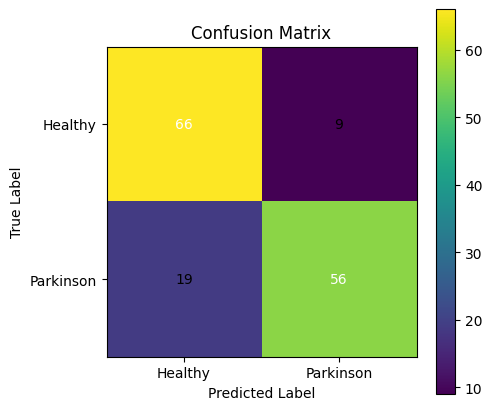

In [55]:
spiral_probs = mobilenet_spiral.predict(spiral_test_gen)
wave_probs   = mobilenet_wave.predict(wave_test_gen)

final_probs = (0.85 * spiral_probs) + (0.15 * wave_probs)
final_preds = (final_probs > 0.5).astype(int)

true_labels = spiral_test_gen.classes

acc = accuracy_score(true_labels, final_preds)
prec = precision_score(true_labels, final_preds)
rec = recall_score(true_labels, final_preds)
f1 = f1_score(true_labels, final_preds)

print("Fused Handwriting Model")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

plot_confusion_matrix(true_labels, final_preds)


In [56]:
def draw_confusion_matrix(model, test_generator, title):

    y_true = test_generator.classes
    y_prob = model.predict(test_generator)
    y_pred = (y_prob > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    plt.xticks([0,1], ["Healthy", "Parkinson"])
    plt.yticks([0,1], ["Healthy", "Parkinson"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     ha="center",
                     va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step


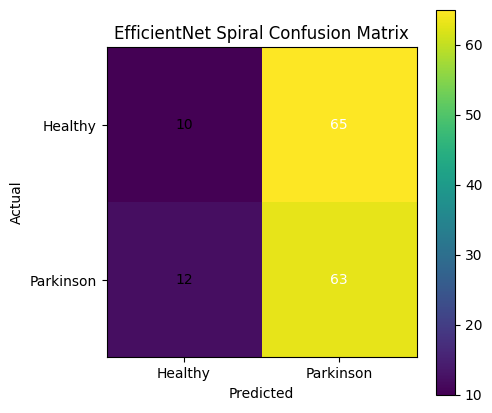

In [57]:
draw_confusion_matrix(
    effnet_spiral,
    spiral_test_gen,
    "EfficientNet Spiral Confusion Matrix"
)


5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


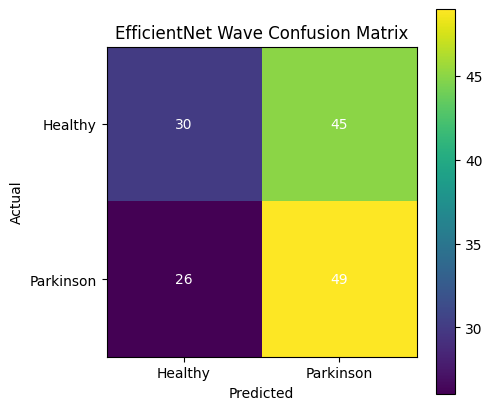

In [58]:
draw_confusion_matrix(
    effnet_wave,
    wave_test_gen,
    "EfficientNet Wave Confusion Matrix"
)


5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step


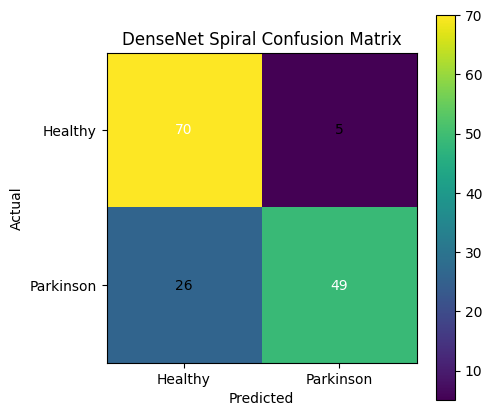

In [59]:
draw_confusion_matrix(
    dense_spiral,
    spiral_test_gen,
    "DenseNet Spiral Confusion Matrix"
)


5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step


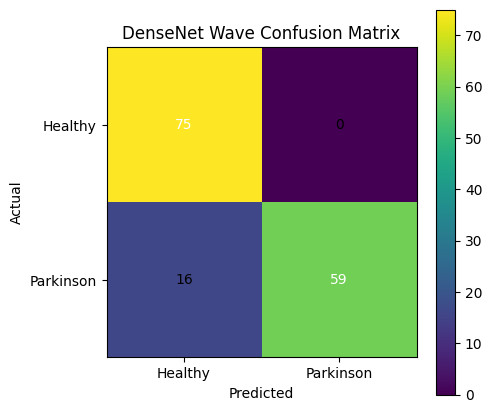

In [60]:
draw_confusion_matrix(
    dense_wave,
    wave_test_gen,
    "DenseNet Wave Confusion Matrix"
)


In [61]:
#load the test probability scores


spiral_probs_dense = dense_spiral.predict(spiral_test_gen).flatten()
wave_probs_dense   = dense_wave.predict(wave_test_gen).flatten()

# Use same lambda weighting as in your paper (0.85 wave + 0.15 spiral)
lambda_w = 0.85
hand_test_probs  = lambda_w * wave_probs_dense + (1 - lambda_w) * spiral_probs_dense
hand_test_labels = spiral_test_gen.classes       # same for both gens

np.save("hand_test_probs.npy",  hand_test_probs)
np.save("hand_test_labels.npy", hand_test_labels)
print("Hand test probs saved:", hand_test_probs.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step
Hand test probs saved: (150,)


In [62]:
#save the test probability scores
spiral_probs_dense = dense_spiral.predict(spiral_test_gen).flatten()
wave_probs_dense   = dense_wave.predict(wave_test_gen).flatten()

lambda_w = 0.85
hand_test_probs  = lambda_w * wave_probs_dense + (1 - lambda_w) * spiral_probs_dense
hand_test_labels = spiral_test_gen.classes       # same for both gens

np.save("hand_test_probs.npy",  hand_test_probs)
np.save("hand_test_labels.npy", hand_test_labels)
print("Hand test probs saved:", hand_test_probs.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
Hand test probs saved: (150,)
